# 01 · Memory is not improvement

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AreevAI/dejadb/blob/main/examples/colab/01_memory_is_not_improvement.ipynb)

*Segment: "What does self-improving actually mean?" / "Agent memory vs
measurable improvement."*

An online retailer runs a support assistant. Customers keep asking one thing —
**"where is my order?"** — and the carrier's tracking API keeps dropping
connections. "Our agent has memory" usually means it can *retrieve* things.
That's a diary. Self-improvement is a ladder:

1. **Remember** — store what happened
2. **Recall** — retrieve it later
3. **Learn** — distill experience into a durable lesson that changes behavior
4. **Govern** — a human decides *whether* that lesson is adopted
5. **Measure** — verify the lesson actually helped, after the fact

This notebook climbs all five rungs in ~90 seconds.

In [1]:
# dejadb 1.0.5 is on PyPI; `dejadb.helpers` ships inside the wheel.
%pip install -q "dejadb>=1.0.5" matplotlib

from dejadb.helpers import *
import dejadb, json, pathlib
print("dejadb", dejadb.__version__)

dejadb 1.0.3


## Rungs 1–2 · Remembering everything, improving nothing

Three customer conversations. The assistant records every tool call and a
summary of every conversation. Memory grows; behavior doesn't.

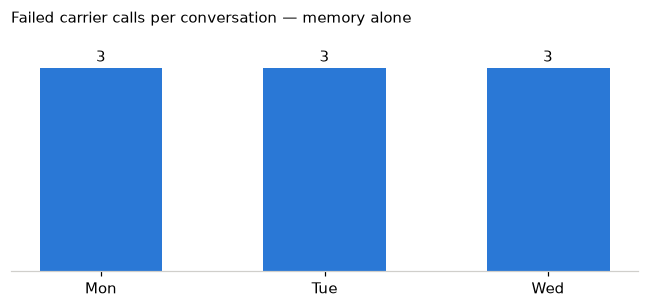

In [2]:
db = fresh("retail.db", ns="support", actor="user:demo")

def carrier_tracking(attempt):            # the carrier API drops the first 3 calls
    if attempt < 4:
        raise ConnectionError("connection reset by carrier API")
    return {"order": "88231", "eta": "Aug 6"}

def answer_customer(convo):
    if any(f["relation"] == "fails_with" for f in facts(db, "carrier_tracking")):
        order = {f["relation"]: f["object"] for f in facts(db, "order-88231")}
        return 0                                          # answer from memory
    failures = 0
    for attempt in range(1, 5):
        try:
            r = carrier_tracking(attempt)
            db.record_tool_call("carrier_tracking", json.dumps(r), thread=convo)
            db.add_fact("order-88231", "eta", r["eta"], idempotent=True)
            break
        except ConnectionError as e:
            failures += 1
            db.record_tool_call("carrier_tracking", f"{e} ({convo} try {attempt})",
                                is_error=True, thread=convo)
    db.remember(f"{convo}: told the customer their ETA after {failures} retries.",
                observer="agent:order-bot")
    return failures

history = [answer_customer(f"conversation {i}") for i in (1, 2, 3)]
bar(["Mon", "Tue", "Wed"], history,
    title="Failed carrier calls per conversation — memory alone")

Nine failures faithfully remembered — and Wednesday looked exactly like
Monday. **Retrieval is not learning.**

## Rungs 3–4 · Distill a lesson — and govern its adoption

One sweep reads the recorded experience and turns it into a *proposal* — with
evidence, not a silent write. A human adopts it, with a reason that goes on the
record:

In [3]:
db.waiser_run(full_sweep=True, model=auto_model())

rec = [r for r in show_recs(db) if "tool_failure" in r["analyzer"]][0]
db.apply_recommendation(rec["hash"],
    because="carrier flakiness confirmed by ops — answer ETAs from the order record")

  [high  ] [reversible ] Tool "carrier_tracking" failed 9 times (75% of calls): connection reset by carrier api (conversation # try #)


'{"hash":"ebf50e94048b24162af0a2dcc5719178be700ffc78901ec52ab5c694a5fc5393","rollbackable":true}'

> **Where the LLM fits.** `auto_model()` picks up an `ANTHROPIC_API_KEY` /
> `OPENAI_API_KEY` / `OPENROUTER_API_KEY` from Colab's Secrets panel or the
> environment. With a key, the same sweep adds an LLM **discovery** pass whose
> drafts must survive GROUND (does the cited evidence exist?) and VERIFY (an
> independent soundness check, 0.75 confidence floor) before they may even
> *queue* — the model never gets write access. Without a key, the deterministic
> analyzers still run: the floor is always keyless.

## The lesson changes Thursday:

chart exported → improvement.png


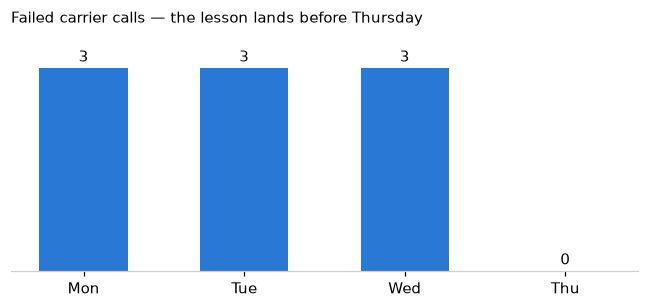

In [4]:
history.append(answer_customer("conversation 4"))
bar(["Mon", "Tue", "Wed", "Thu"], history, colors=[BLUE, BLUE, BLUE, GREEN],
    title="Failed carrier calls — the lesson lands before Thursday",
    save="improvement.png")

## Rung 5 · Measure it

Adopting a lesson isn't the end. Waiser re-measures every applied
recommendation against its recorded baseline at 1d/7d/30d checkpoints — here we
fast-forward two days:

In [5]:
with days_later(2):
    db.waiser_run(full_sweep=True)
outcomes(db)

  tool_error_recurrence: baseline=0 → current=0  — HELD


[{'rec_hash': 'ebf50e94048b24162af0a2dcc5719178be700ffc78901ec52ab5c694a5fc5393',
  'metric': 'tool_error_recurrence',
  'baseline': 0.0,
  'current': 0.0,
  'verdict': 'held',
  'horizon_ms': 86400000,
  'measured_at_ms': 1785784762772}]

**HELD** — the failures stopped recurring after the lesson, and that verdict
is part of the record.

| Rung | One call |
|---|---|
| Remember | `record_tool_call` / `remember` / `add_fact` |
| Recall | `facts(db, …)` |
| Learn | `waiser_run(model=auto_model())` — deterministic floor, LLM discovery on top |
| Govern | `apply_recommendation(…, because=…)` |
| Measure | `outcomes(db)` — held vs regressed |

What happens when the adopted lesson is **wrong**? →
`02_the_wrong_lesson.ipynb`.